In [2]:
from pathlib import Path
import json
import pandas as pd

import cv2
import numpy as np
import torch
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor

import matplotlib.pyplot as plt

from tqdm.auto import tqdm
tqdm.pandas()

/Users/superbg/mamba/envs/idmybee/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
PROJECT_ROOT = Path.cwd().parent
LOGS_PATH = PROJECT_ROOT / 'logs' / 'wing_extraction_log.csv'
REFERENCE_PATH = PROJECT_ROOT / 'data' / 'references' / 'ref.json'

INPUT_DIR = PROJECT_ROOT / 'data' / 'images' / 'organized'
OUTPUT_DIR = PROJECT_ROOT / 'out' / 'predicted_crops'

wing_crops = pd.read_csv(LOGS_PATH, index_col=0)
wing_crops = wing_crops.loc[wing_crops.status == 'OK']
wing_crops.head()

,image,status,x,y,w,h,theta,confidence,similarity,aspect_ratio,n_detections,input_path,output_path
idx,,,,,,,,,,,,,
0,Bombus_confusus/male/FR15ABOM150820018_P1.JPG,OK,2394.0,1767.0,504.0,1282.0,0.0,0.855,0.948,2.55,1,data/images/organized/Bombus_confusus/male/FR1...,data/images/wing_crops/Bombus_confusus/male/FR...
1,Bombus_confusus/male/FR15ABOM150820018_P2.JPG,OK,2377.0,1803.0,508.0,1297.0,0.0,0.785,0.944,2.55,1,data/images/organized/Bombus_confusus/male/FR1...,data/images/wing_crops/Bombus_confusus/male/FR...
2,Bombus_confusus/male/FR15ABOM150820018_S1.jpg,OK,1437.0,1732.0,386.0,969.0,0.0,0.844,0.869,2.51,2,data/images/organized/Bombus_confusus/male/FR1...,data/images/wing_crops/Bombus_confusus/male/FR...
3,Bombus_confusus/male/FR15ABOM150820018_S2.jpg,OK,1455.0,1799.0,402.0,1004.0,0.0,0.843,0.913,2.50,2,data/images/organized/Bombus_confusus/male/FR1...,data/images/wing_crops/Bombus_confusus/male/FR...
4,Bombus_confusus/male/FR15ABOM150820018_S3.jpg,OK,1441.0,1662.0,402.0,1000.0,0.0,0.896,0.914,2.49,1,data/images/organized/Bombus_confusus/male/FR1...,data/images/wing_crops/Bombus_confusus/male/FR...


In [28]:
def load_references(ref_json_path: str):
    """Retourne une liste de (image_path, boxes) -- 1 ou plusieurs entrées."""
    import json
    with open(ref_json_path) as f:
        data = json.load(f)
    if isinstance(data, dict):
        data = [data]
    return [(Path(PROJECT_ROOT / entry["image"]), np.array(entry["boxes"], dtype=np.float32)) for entry in data]


def compute_vpe(model, image_path: str, boxes: np.ndarray, predictor_cls, imgsz: int = 1024, device=None):
    from ultralytics.cfg import get_cfg

    visual_prompts = dict(bboxes=boxes, cls=np.zeros(len(boxes), dtype=int))
    if type(model.predictor) is not predictor_cls:
        args = get_cfg(overrides={**model.overrides, "imgsz": imgsz, "device": device})
        model.predictor = predictor_cls(
            overrides={
                "task": model.model.task, "mode": "predict", "save": False, "verbose": False,
                "batch": 1, "device": args.device, "quantize": args.quantize, "imgsz": args.imgsz,
            },
            _callbacks=model.callbacks,
        )
    model.model.model[-1].nc = 1
    model.model.names = ["object0"]
    model.predictor.set_prompts(visual_prompts.copy())
    model.predictor.setup_model(model=model.model, verbose=False)
    return model.predictor.get_vpe(image_path)

def bake_references(model, references, predictor_cls, imgsz: int = 1024, device=None):
    vpes = [compute_vpe(model, img, boxes, predictor_cls, imgsz, device) for img, boxes in references]
    avg_vpe = torch.mean(torch.stack(vpes, dim=0), dim=0)
    avg_vpe = avg_vpe / avg_vpe.norm(dim=-1, keepdim=True)  # les VPE individuels sont unitaires
    model.model.set_classes(["object0"], avg_vpe)
    model.model.names = ["object0"]
    model.predictor = None  # un predicteur standard sera recréé au 1er predict() réel

In [31]:
model = YOLOE("../data/models/yoloe-11s-seg.pt")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

references = load_references(REFERENCE_PATH)
bake_references(model, references, YOLOEVPSegPredictor, imgsz=1024, device=device)

device

'cpu'

In [32]:
idxs = [0, 10, 100, 232]#, 980, 1000, 1001, 1295, 1536, 2016]
target_images = [PROJECT_ROOT / wing_crops.loc[idx].input_path for idx in idxs]

In [33]:
results = model.predict(
    target_images,
    conf=0.05,
    imgsz=1024,
    device=device,
    verbose=False,
)

2 détection(s) sur l'image cible :
  [0] bbox=[1743.0, 1510.6, 3037.8, 2021.6]  conf=0.896
  [1] bbox=[2362.1, 1510.9, 2772.0, 1587.8]  conf=0.117
1 détection(s) sur l'image cible :
  [0] bbox=[1778.2, 1536.2, 3188.2, 2110.1]  conf=0.892
1 détection(s) sur l'image cible :
  [0] bbox=[1657.7, 1436.1, 3165.5, 2145.5]  conf=0.772
4 détection(s) sur l'image cible :
  [0] bbox=[860.2, 1675.7, 1909.7, 2102.7]  conf=0.893
  [1] bbox=[1537.5, 0.0, 2785.6, 226.3]  conf=0.718
  [2] bbox=[47.8, 724.4, 804.2, 1528.0]  conf=0.119
  [3] bbox=[313.5, 2122.7, 426.5, 2256.1]  conf=0.054


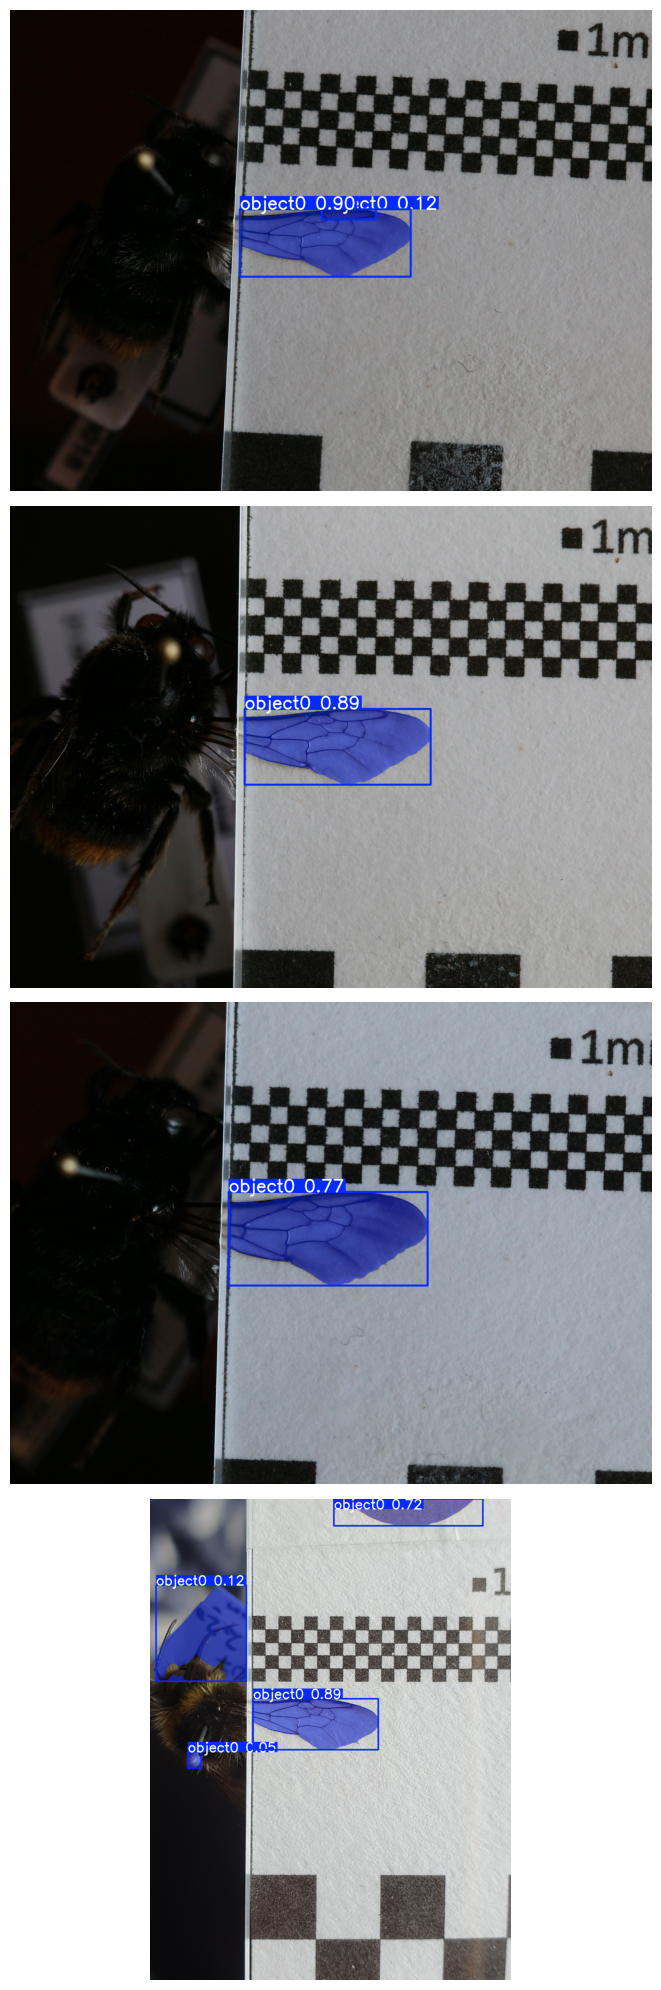

In [34]:
fig, axes = plt.subplots(len(results), 1, figsize=(7, 5*len(results)))

for idx, r in enumerate(results):
    n_det = len(r.boxes) if r.boxes is not None else 0
    print(f"{n_det} détection(s) sur l'image cible :")
    for i in range(n_det):
        xyxy = r.boxes.xyxy[i].tolist()
        conf = float(r.boxes.conf[i])
        print(f"  [{i}] bbox={[round(v, 1) for v in xyxy]}  conf={conf:.3f}")

    annotated_img = r.plot()
    cv2.resize(annotated_img, None, fx=0.5, fy=0.5)
    axes[idx].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

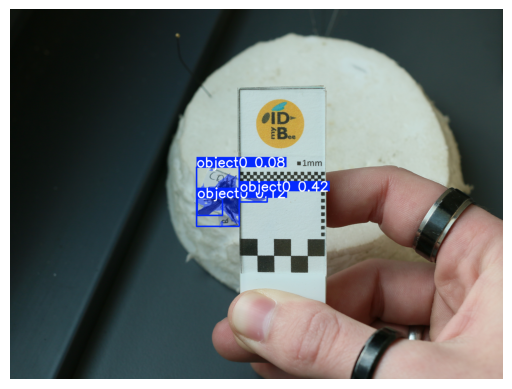

In [38]:
image_path = str(INPUT_DIR / wing_crops.loc[1283].image)
image = cv2.imread(image_path)

results = model.predict(image, conf=0.05, imgsz=1024, device=device, verbose=False)
r = results[0]
annotated_img = r.plot()

cv2.resize(annotated_img, None, fx=0.5, fy=0.5)
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [39]:
n_det = len(r.boxes) if r.boxes is not None else 0
confs = r.boxes.conf.cpu().numpy()
best = int(confs.argmax())

print(f"{n_det} objets trouvées, confs: {confs}")
print("best:", best)

3 objets trouvées, confs: [    0.42139     0.11501    0.081136]
best: 0


In [ ]:
points = r.masks.xy[best]
rect = cv2.minAreaRect(points.astype(np.float32))
obb_corners = cv2.boxPoints(rect)

(x0, y0), (w_rect, h_rect), theta = rect

print(f"({x0:.2f},{y0:.2f}) / ({w_rect:.2f},{h_rect:.2f}) / {theta:.2f}°")

(2470.27,1817.79) / (1316.11,671.81) / -11.70°


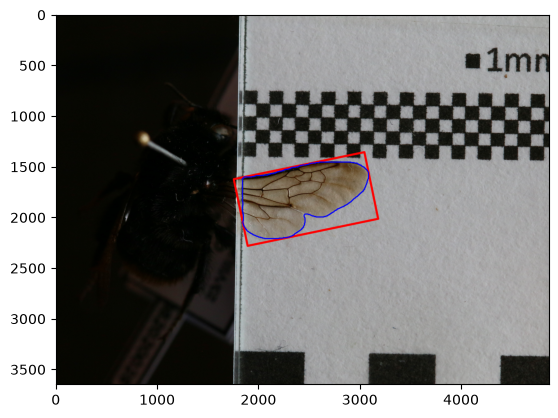

In [ ]:
output = image.copy()

obb = np.array(obb_corners, np.int32).reshape((-1, 1, 2))
pts = np.array(points, np.int32).reshape((-1, 1, 2))

output = cv2.polylines(output, [obb], True, (0,0,255), 20)
output = cv2.polylines(output, [pts], True, (255,0,0), 10)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
edge1 = obb_corners[1] - obb_corners[0]
edge2 = obb_corners[2] - obb_corners[1]
long_edge = np.linalg.norm(edge2) >= np.linalg.norm(edge1)

print(long_edge)

rotation_angle = theta if long_edge else 90 + theta

print(f"Angle de rotation : {rotation_angle:.2f}°")

False
Angle de rotation : 0.00°


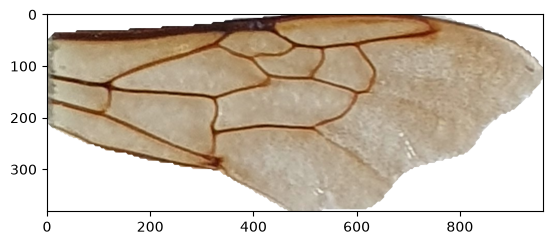

In [ ]:
h, w = image.shape[:2]
center = (w / 2, h / 2)

M = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
cos, sin = abs(M[0, 0]), abs(M[0, 1])
new_w, new_h = int(h * sin + w * cos), int(h * cos + w * sin)
M[0, 2] += new_w / 2 - center[0]
M[1, 2] += new_h / 2 - center[1]

rotated = cv2.warpAffine(image, M, (new_w, new_h), borderValue=(255,255,255))

mask_full = np.zeros((h, w), dtype=np.uint8)
cv2.fillPoly(mask_full, [points.astype(np.int32)], 255)
rotated_mask = cv2.warpAffine(mask_full, M, (new_w, new_h), borderValue=0)
rotated[rotated_mask == 0] = (255,255,255)

corners_h = np.hstack([obb_corners, np.ones((4, 1))])
rotated_corners = (M @ corners_h.T).T
x_min, y_min = rotated_corners.min(axis=0)
x_max, y_max = rotated_corners.max(axis=0)
x_min, y_min = max(0, int(round(x_min))), max(0, int(round(y_min)))
x_max, y_max = min(new_w, int(round(x_max))), min(new_h, int(round(y_max)))

crop = rotated[y_min:y_max, x_min:x_max]

plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.show()